---
format:
  html:
    code-fold: true
execute:
  echo: true
---

[← Back to article notes](../index.qmd)

# Project

## Table of Contents:
  - [Introduction](#introduction)
      - Inviscid Burgers' equation
      - Viscous Burgers' equation and Jin-Xin's model
  - [Other Works](#other-works)
      - IMEX methods
      - RelaxNN architectures

## Introduction <a name="introduction"></a>

Let $u\in C^1\left(\mathbb{R}\times\mathbb{R}^+;\mathbb{R}\right)$ be the state variable of the equation, and $f\in C^1\left(\mathbb{R};\mathbb{R}\right)$ be the flux function (in the classical definition, $f(u)=\frac12 u^2$). The inviscid Burgers' equation is defined as follows:

$$\partial_t u + \partial_x f(u) = 0$$

### Shockwaves and Information

Given a characteristic curve $\varphi(t)$ with initial value $u_0=u(\varphi(0),0)$, we observe that:

$$
\begin{align*}
&\partial_t u\left(\varphi(t),t\right) + \partial_x f\left(u\right)\left(\varphi(t),t\right) = 0\\
&0 = \frac{\mathrm{d} u\left(\varphi(t),t\right)}{\mathrm{d}t} = {\partial_t u}\left(\varphi(t),t\right) + \varphi'(t){\partial_x u}\left(\varphi(t),t\right)
\end{align*}
$$

Thus, $\varphi'(t)=\frac{\partial_x f\left(u\right)}{\partial_x u}\left(\varphi(t),t\right) = f'(u\left(\varphi(t),t\right)) = f'(u_0)$.

When two characteristic curves carrying different states meet, a shockwave is formed. This occurs when there exist initial points $x_0 < x_1$ such that $f'(u_0)>f'(u_1)$. Specifically, the information originating from $x_0$ collides with that of $x_1$ at time $t_\textrm{shock} = \frac{x_1-x_0}{f'(u_0) - f'(u_1)}$, provided the respective information survives until this time without being absorbed by other interactions.

Shockwaves' dynamics: Let $x_s(t)$ be the position of a shockwave separating the states $u_L$ and $u_R$. Given a control volume $[x_1,x_2]$ such that $x_s(t)\in[x_1,x_2]$, we observe that:

$$\begin{align*}
    \frac{\mathrm{d}}{\mathrm{d}t} \int_{x_1}^{x_s(t)} u(x,t) dx &= \int_{x_1}^{x_s(t)}\partial_t udx + u_L\frac{\mathrm{d}x_s(t)}{\mathrm{d}t}
    \\
    \frac{\mathrm{d}}{\mathrm{d}t} \int_{x_s(t)}^{x_2} u(x,t) dx &= \int_{x_s(t)}^{x_2}\partial_t udx - u_R\frac{\mathrm{d}x_s(t)}{\mathrm{d}t}
    \end{align*}$$

And thus:

$$\frac{\mathrm{d}}{\mathrm{d}t} \int_{x_1}^{x_2} u(x,t) dx = \int_{x_1}^{x_2}\partial_t udx + \left(u_L - u_R\right)\frac{\mathrm{d}x_s(t)}{\mathrm{d}t}$$

From the conservation law in integral form, we also have:

$$\frac{\mathrm{d}}{\mathrm{d}t} \int_{x_1}^{x_2} u(x,t) dx = f(u_L) - f(u_R)$$

Taking the limit as the spatial interval shrinks to the shock position $x_1 \to x_s(t)$ and $x_2 \to x_s(t)$, the integrals of the partial derivatives vanish, yielding the Rankine-Hugoniot jump condition:

$$\begin{align*}
    \left(u_L - u_R\right)\frac{\mathrm{d}x_s(t)}{\mathrm{d}t} &= f(u_L) - f(u_R)
    \\
    x_s'(t)=\frac{\mathrm{d}x_s(t)}{\mathrm{d}t} &= \frac{f(u_L) - f(u_R)}{u_L - u_R}
    \end{align*}$$

### Loss of information

Assuming that $f$ is a strictly convex function, the Lax entropy condition ensures that $x_s'(t)\in\left[f'(u_R),f'(u_L)\right]$. The shockwave "absorbs" the information carried by the characteristic curves.
We can compute the relative rates at which the shockwave overtakes the surrounding information as follows:

$$r_L(t) = f'(u_L(t)) - x_s'(t), \quad r_R(t) = x_s'(t) - f'(u_R(t))$$

This irreversible absorption is the basis of the entropy analysis for this equation. In particular, a physical shockwave increases the entropy of the system, making it impossible to perfectly reconstruct the previous exact information backward in time.

### Summary of the Dynamics

- **Velocity of the information:** <br> $\frac{\mathrm{d}\varphi(t)}{\mathrm{d}t} = \varphi'(t) = f'(u_0)$ where $u_0=u(\varphi(0),0)$.

- **Velocity of a shockwave:** <br> $\frac{\mathrm{d} x_s(t)}{\mathrm{d}t} = x_s'(t) = \frac{f(u_L)-f(u_R)}{u_L-u_R}$ where $u_L, u_R$ are the boundary values at the shock.

- A shockwave irreversibly erases local information over time.

### Viscosity and the Jin-Xin model

The main variant of the inviscid Burgers' equation is the viscous Burgers' model, defined as follows:

$$\partial_t u + \partial_x f(u) = \nu\partial_{xx} u$$

This is a parabolic equation due to the second-order viscous term.

The Jin-Xin model is a hyperbolic relaxation system that implicitly acts as a viscous approximation of the Burgers' equation. It is defined as follows:

$$\begin{cases}
        \partial_t u + \partial_x v = 0\\
        \partial_t v + a \partial_x u = -\frac1\varepsilon\left(v-f(u)\right)
    \end{cases}$$

Using the Chapman-Enskog expansion, we can link the Jin-Xin model with the viscous Burgers' equation. Let $u, v$ be the solutions parameterized by the relaxation time $\varepsilon$. We expand the flux $v$ as $v=v_0+\varepsilon v_1 + \varepsilon^2 v_2 + \mathcal{O}\left(\varepsilon^3\right)$:

$$
\begin{cases}
    \partial_t u + \partial_x \left(v_0+\varepsilon v_1+\mathcal{O}\left(\varepsilon^2\right)\right) = 0\\
    v_0+\varepsilon v_1 + \mathcal{O}\left(\varepsilon^2\right) = f(u) - \varepsilon\left(\partial_t \left(v_0+\varepsilon v_1+\mathcal{O}\left(\varepsilon^2\right)\right) + a \partial_x u\right)
\end{cases}
$$

By matching the $\mathcal{O}(1)$ terms, we get the first-order local equilibrium:

$$\begin{cases}
        \partial_t u + \partial_x \left(v_0\right) = 0\\
        v_0 = f(u)
    \end{cases} \quad (\textrm{Zeroth order})$$

Using this zeroth-order approximation, we evaluate the $\mathcal{O}(\varepsilon)$ correction term:

$$\begin{align*}
        v_1 &= - \left(\partial_t v_0 + a \partial_x u\right)\\
            &= - \left(f'(u)\partial_t u + a \partial_x u\right)\\
            &= - \left(f'(u)\left(-\partial_x v_0\right) + a \partial_x u\right)\\
            &= - \left(f'(u)\left(-f'(u)\partial_x u\right) + a \partial_x u\right)\\
            &= - \left(a - \left(f'(u)\right)^2\right)\partial_x u
    \end{align*}$$

Thus, the flux up to the first order is:

$$v \approx v_0 + \varepsilon v_1 = f(u) - \varepsilon \left(a - \left(f'(u)\right)^2\right)\partial_x u$$

Substituting this back into the first equation yields:

$$
\begin{align*}
    &\partial_t u + \partial_x \left(f(u) - \varepsilon \left(a - \left(f'(u)\right)^2\right)\partial_x u\right) \approx 0\\
    &\partial_t u + \partial_x f(u) \approx \varepsilon \partial_x\left(\left(a - \left(f'(u)\right)^2\right)\partial_x u\right)
\end{align*}
$$

The effective viscosity coefficient depends on $u$ and is defined as follows:

$$\nu(u) = \varepsilon \left(a - \left(f'(u)\right)^2\right)$$

Depending on the sign of this coefficient, we recognize two regimes:

- **Anti-diffusion:** $a < \left(f'(u)\right)^2$. The viscosity is negative, and the problem is ill-posed (exponentially unstable).

- **Sub-characteristic condition:** $a > \left(f'(u)\right)^2$. The viscosity is strictly positive, which is required for a physically and mathematically well-posed problem.

### Summary:

- The viscous Burgers' model is defined as $\partial_t u + \partial_x f(u) = \nu\partial_{xx} u$

- The Jin-Xin's model behaves asymptotically ($\varepsilon \to 0$) as $\partial_t u + \partial_x f(u) \approx \partial_x \left(\nu(u)\partial_x u\right)$, where $\nu(u)=\varepsilon \left(a - \left(f'(u)\right)^2\right)$.

- The viscous Burgers' model is a parabolic equation.

- The Jin-Xin's model remains a strictly hyperbolic system.

- We require the sub-characteristic condition $a > \left(f'(u)\right)^2$ to guarantee stability.

### Physics-Informed Neural Networks (PINNs) Analysis

If we want to implement a PINN for one of these models (inviscid Burgers, viscous Burgers, or Jin-Xin), we observe the following architectural challenges:

- **Inviscid Burgers:** A PINN is inherently a continuous function and struggles to learn high-frequency features. A perfect discontinuity can only be approximated by infinitely high frequencies (spectral bias problem). Even if the neural network manages to approximate a sharp gradient, the spatial derivative explodes, leading to an explosion of the local PDE residual during training.

- **Viscous Burgers:** The computation of the second derivative ($\partial_{xx} u$) via automatic differentiation is computationally demanding and scales poorly. Furthermore, second-order derivatives heavily amplify the noise, increasing the complexity and non-convexity of the loss landscape.

- **Jin-Xin:** This system solves the aforementioned drawbacks by maintaining a first-order structure and yielding smooth solutions. However, when trying to capture the inviscid limit ($\varepsilon \approx 0$), the source term $\frac{1}{\varepsilon}$ diverges, leading once again to gradient explosion (stiffness) and requiring Asymptotic-Preserving formulations.

## Other Works <a name="other-works"></a>

In the literature, we find two main classes of schemes to solve the Jin-Xin model: classical numerical schemes and Physics-Informed Neural Networks (PINNs). Here are the state-of-the-art examples for both approaches:

- **Implicit-Explicit (IMEX) schemes:** These methods treat the non-stiff differential part explicitly (avoiding costly nonlinear system inversions) and the stiff relaxation term implicitly. A properly designed IMEX scheme possesses the Asymptotic-Preserving (AP) property: it transitions seamlessly to a consistent and stable macroscopic solver for the inviscid Burgers' equation as $\varepsilon \to 0$, without suffering from restrictive CFL constraints.

- **RelaxNN (Relaxation Neural Networks):** Representing the current state-of-the-art for hyperbolic relaxation in SciML, RelaxNN frameworks fundamentally reformulate the PDE residuals to bypass the stiffness. Instead of dividing by $\varepsilon$, the residuals are scaled appropriately (e.g., multiplying the governing equations by $\varepsilon$ or reformulating the loss to separate the equilibrium penalty from the flux gradient). This balancing act equalizes the backpropagated gradients, preventing the Neural Tangent Kernel (NTK) from diverging and allowing the network to uniformly converge to the correct shock profile independently of the magnitude of the relaxation time.

### IMEX Methods

A first-order IMEX method for the Jin-Xin system can be described as follows:
$$
    \begin{cases}
        \frac{u^{n+1} - u^{n}}{\Delta t} + \partial_x v^{n} = 0
        \\
        \frac{v^{n+1}-v^{n}}{\Delta t} + a \partial_x u^{n} = -\frac1\varepsilon \left(v^{n+1}-f(u^{n+1})\right)
    \end{cases}
$$
In particular, we apply an explicit scheme for the first equation (transport term) to compute $u^{n+1}$, and then an implicit scheme for the second equation to compute $v^{n+1}$ evaluating the stiff relaxation term at the new time step.

**Drawbacks:**
- Designing high-order IMEX Runge-Kutta methods that are rigorously AP and uniformly stable is algebraically complex.

### RelaxNN Architecture

The standard approach for a PINN requires the formulation of a physical loss function. For the Jin-Xin relaxation equation, it contains the following residual:

$$\mathcal{R}_{standard} = \partial_t v + a \partial_x u + \frac{1}{\varepsilon} \left(v-f(u)\right)$$

However, if $\varepsilon \ll 1$, the training process is completely dominated by the penalty term $\frac{1}{\varepsilon}(v-f(u))$. The optimizer ignores the differential operators, severely degrading the performance of the training and leading to the so-called Gradient Pathology.

To overcome this, the current state-of-the-art relies on a Macro-Micro decomposition, employing two separate neural networks (or two distinct outputs). We define the perturbation $w$ as follows:

$$v = f(u) - \varepsilon\left(\partial_t v + a \partial_x u\right) = f(u) + \varepsilon w$$

where $w$ is another function that describes the microscopic perturbation of $v$ from the local equilibrium flux $f(u)$.

Instead of estimating $u$ and $v$ directly, we estimate $u$ and $w$ to reconstruct the original variables. We can rewrite the Jin-Xin model using these new coordinates:

$$\begin{cases}
        \begin{aligned}
            0 &= \partial_t u + \partial_x v \\
              &= \partial_t u + \partial_x \left(f(u) + \varepsilon w\right) \\
              &= \partial_t u + \partial_x f(u) + \varepsilon \partial_x w
        \end{aligned}
        \\[10pt]
        \begin{aligned}
            -w &= - \frac{1}{\varepsilon}\left(f(u) + \varepsilon w - f(u)\right) \\
               &= - \frac{1}{\varepsilon}\left(v - f(u)\right) \\
               &= \partial_t v + a\partial_x u \\
               &= \partial_t \left(f(u) + \varepsilon w\right) + a\partial_x u \\
               &= \partial_t f(u) + \varepsilon \partial_t w + a\partial_x u
        \end{aligned}
    \end{cases}$$

The final Macro-Micro model becomes:

$$\begin{cases}
        \partial_t u + \partial_x f(u) + \varepsilon \partial_x w = 0
        \\[6pt]
        w + \partial_t f(u) + a\partial_x u + \varepsilon \partial_t w = 0
    \end{cases}$$

This represents an APNN (Asymptotic-Preserving Neural Network) formulation. Indeed, as $\varepsilon \to 0$, the singularity $\frac{1}{\varepsilon}$ has completely disappeared from the loss function, and we perfectly recover the asymptotic limit:
$$
    \begin{cases}
        \partial_t u + \partial_x f(u) = 0 & (\textrm{Inviscid Burgers' Equation})
        \\[6pt]
        w = -\left(\partial_t f(u) + a\partial_x u\right) & (\textrm{Micro Equation})
    \end{cases}
$$

**Drawbacks:**

- **Computational Cost:** Training a PINN involves minimizing a highly non-convex loss function over many epochs, making it significantly more computationally expensive than the sequential time-stepping of a classical numerical scheme.

- **Residual Spectral Bias:** Although RelaxNN solves the gradient pathology, neural networks inherently struggle to represent perfect mathematical discontinuities (like a pure Heaviside step at $\varepsilon=0$). The network output will typically exhibit a slightly smoothed shock profile.

- **Hyperparameter Sensitivity:** Balancing the loss weights between the macroscopic network, microscopic network, and boundary/initial conditions requires meticulous tuning.

### Summary

To highlight the structural differences between these state-of-the-art approaches, we compare them across several critical dimensions:


| Feature | IMEX | RelaxNN |
| --- | --- | --- |
| Asymptotic-Preserving (AP) | Requires highly complex algebraic design to satisfy stiff accuracy conditions (e.g., specific Butcher tableaus). | Naturally and elegantly achieved through architectural design (Macro-Micro analytical splitting). |
| Computational Cost | Extremely fast and efficient for a single forward simulation. | Expensive and time-consuming to train. However, once trained, inference is exceptionally fast and allows continuous evaluations. |
| Accuracy & Shockwaves | High accuracy relies on advanced shock-capturing limiters (e.g., WENO, TVD). Prone to numerical diffusion or dispersion at low resolution. | Provides a globally continuous analytical approximation. Suffers from spectral bias, rendering shocks slightly smoother than classical schemes but inherently avoiding Gibbs oscillations. |
| Grid Dependence   | Grid-dependent. Subjected to CFL constraints (though relaxed by implicit terms). | Completely mesh-free. The solution can be evaluated at any arbitrary, continuous spatiotemporal coordinate. |
| Dimensionality & Scaling      | Suffers drastically from the "curse of dimensionality". | Scales exceptionally well to high-dimensional PDEs and inverse problems (parameter estimation). |

### Remarks on High-Dimensionality

A notable advantage of applying PINN-based approaches like RelaxNN is their scalability to higher dimensions. The multi-dimensional Jin-Xin model is defined as:
$$
    \begin{cases}
        \partial_t u + \nabla_x \cdot v = 0
        \\
        \partial_t v + D \nabla_x u = -\frac1\varepsilon\left(v - f(u)\right)
    \end{cases}
$$
where $x \in \mathbb{R}^n$, the state variable is $u: \mathbb{R}^n \times \mathbb{R}^+ \to \mathbb{R}$, the flux variable is a vector field $v: \mathbb{R}^n \times \mathbb{R}^+ \to \mathbb{R}^n$, and $f(u) = (f_1(u), \dots, f_n(u))^T$.
To ensure strict hyperbolicity and physical stability, $D \in \mathbb{R}^{n\times n}$ must be a diagonal positive-definite matrix $D = \text{diag}(d_1, \dots, d_n)$ satisfying the sub-characteristic condition for each spatial dimension:
$$d_i > (f_i'(u))^2 \quad \text{for } i = 1, \dots, n$$

The PDE of the RelaxNN will be:
$$
\begin{align*}
    &\begin{cases}
        \partial_t u + \nabla_x \cdot \left(f(u) + \varepsilon w\right) = 0
        \\
        \partial_t \left(f(u) + \varepsilon w\right) + D \nabla_x u = -\frac1\varepsilon\left(\left(f(u) + \varepsilon w\right) - f(u)\right)
    \end{cases}\\
    &\begin{cases}
        \partial_t u + \nabla_x \cdot f(u) = -\varepsilon\nabla_x \cdot w
        \\
        w = -\partial_t f(u) - \varepsilon \partial_t w - D \nabla_x u
    \end{cases}
\end{align*}
$$
with limit:
$$
    \begin{cases}
        \partial_t u + \nabla_x \cdot f(u) = 0
        \\
        w = -\partial_t f(u) - D \nabla_x u
    \end{cases}
$$

## Implementation

### IMEX 1D

In this implementation we use the Rusanov flux for the computation of $\partial_x u$ and $\partial_x v$. For this purpose, we rewrite the Jin-Xin model as follows:
$$
    \partial_t U + \partial_x F(U) = h(U)
$$
where: $U=(u,v)$, $F(U)=(v,au)$, $h(U)=\left(0,-\frac1\varepsilon\left(v-f(u)\right)\right)$.

The Rusanov flux computes an intermediate state and then we use it to compute the derivative of $U$:
$$
    \begin{align*}
        &R_{i} = \frac{F(U)_{i-\frac12}+F(U)_{i+\frac12}}{2} - \sqrt{a}\frac{U_{i+\frac12}-U_{i-\frac12}}{2} \\&\quad
        \begin{cases}
            r_{i}^{(1)} = \frac{v_{i-\frac12}+v_{i+\frac12}}{2} - \sqrt{a}\frac{u_{i+\frac12}-u_{i-\frac12}}{2}
            \\
            r_{i}^{(2)} = a\frac{u_{i-\frac12}+u_{i+\frac12}}{2} - \sqrt{a}\frac{v_{i+\frac12}-v_{i-\frac12}}{2}
        \end{cases} \quad\forall i=\frac12,\frac32,\ldots \\[2ex]
        &\left(\partial_x F(U)\right)_{k} = \frac{R_{k+\frac12}-R_{k-\frac12}}{\Delta x} \\&\quad
        \begin{cases}
            \left(\partial_x v\right)_{k} = \frac{r_{k-\frac12}^{(1)}+v_{k+\frac12}^{(1)}}{\Delta x}
            \\
            \left(\partial_x au\right)_{k} = \frac{r_{k-\frac12}^{(2)}+v_{k+\frac12}^{(2)}}{\Delta x}
        \end{cases} \quad\forall k=1,2,\ldots
    \end{align*}
$$
We use this approximation to solve the step:
$$
\begin{align*}
    &\begin{cases}
        \frac{u^{t+1}-u^{t}}{\Delta t} + \left(\partial_x v^t\right) = 0
        \\
        \frac{v^{t+1}-v^{t}}{\Delta t} + \left(\partial_x au^t\right) = -\frac1\varepsilon\left(v^{t+1}-f(u^{t+1})\right)
    \end{cases} \\\implies&
    \begin{cases}
        u^{t+1} = u^t - \Delta t\left(\partial_x v^t\right)
        \\
        v^{t+1} = \frac{\varepsilon}{\varepsilon+\Delta t}\left(v^{t}-\Delta t\left(\partial_x au^t\right)\right) + \frac{\Delta t}{\varepsilon+\Delta t}f(u^{t+1})
    \end{cases}
\end{align*}
$$

In [1]:
#| code-summary: "import libraries"
from math import sqrt
import torch
from torch import nn
from torch.nn import functional as F
import numpy as np
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, display
import diffutils as dfu
from typing import Callable, Any

In [2]:
#| code-summary: "Functions"
def f(u: torch.Tensor, d: int) -> torch.Tensor:
    """u has shape (B,)
    f(u) has shape (B, d)"""
    r = 0.5 * u ** 2
    return torch.stack([r]*d, dim=-1)
def df(u: torch.Tensor, d: int) -> torch.Tensor:
    """u has shape (B,)
    df(u) has shape (B, d)"""
    return torch.stack([u]*d, dim=-1)

In [3]:
#| code-summary: "IMEX scheme for 1D Jin-Xin relaxation system"
def compute_fluxes(u, v, a, Dx):
    sqrt_a = sqrt(a)
    
    u_pad = F.pad(u[None, :], (1,1), mode='replicate')[0]
    v_pad = F.pad(v[None, :], (1,1), mode='replicate')[0]
    
    u_L = u_pad[:-1]
    u_R = u_pad[1:]
    v_L = v_pad[:-1]
    v_R = v_pad[1:]
    
    v_flux  = 0.5 * (v_L + v_R) - 0.5 * sqrt_a * (u_R - u_L)
    au_flux = 0.5 * a * (u_L + u_R) - 0.5 * sqrt_a * (v_R - v_L)
    
    difv = (v_flux[1:] - v_flux[:-1]) / Dx
    adifu = (au_flux[1:] - au_flux[:-1]) / Dx
    
    return adifu, difv

def imex_step(u, v, Dt, Dx, eps, a):
    adifu, difv = compute_fluxes(u, v, a, Dx)
    
    # explicit step: u is updated by the derivatives of v
    u_next = u - Dt * difv
    
    # implicit step: v relaxes towards f(u_next)
    v_next = (eps * v - eps * Dt * adifu + Dt * f(u_next, 1)[0]) / (eps + Dt)
    
    return u_next, v_next

# --- SETUP ---
L: float = 10.0   # Spatial domain length
T: float = 5.0    # Final time
N: int = 40000    # Number of spatial points
Dx: float = L / N
a: float = 1.1    # Sub-characteristic condition: a > u^2. Since u max = 1, a=1.1 is safe.

# 1D Courant-Friedrichs-Lewy Condition
Dt: float = Dx / sqrt(a)
eps: float = 0.005
steps: int = int(T / Dt)

x: torch.Tensor = torch.linspace(-L/2, L/2, N)
u: torch.Tensor = torch.exp(- 0.5 * x**2)  # Shape: (N,)
v: torch.Tensor = f(u, 1)[:, 0]  # Shape: (N,)

u_init_np = u.squeeze().numpy()
v_init_np = v.squeeze().numpy()

u_history = np.empty((steps, N), dtype=np.float32)
v_history = np.empty((steps, N), dtype=np.float32)

for n in range(steps):
    u, v = imex_step(u, v, Dt, Dx, eps, a)
    u_history[n] = u.cpu().numpy()
    v_history[n] = v.cpu().numpy()

In [4]:
#| echo: false
#| code-summary: "animation in html"
"""fig, ax = plt.subplots(figsize=(8, 4.5))
lineu_init, = ax.plot([], [], label=r"initial $u$", lw=1, color='black', ls='--')
linev_init, = ax.plot([], [], label=r"initial $v$", lw=1, color='black', ls='--')
lineu, = ax.plot([], [], label=r"$u$", lw=2, color='blue')
linefu, = ax.plot([], [], label=r"$f(u)$", lw=1, color='green', ls=':')
linev, = ax.plot([], [], label=r"$v$", lw=2, color='orange')
title = ax.text(0.5, 1.02, "", transform=ax.transAxes, ha="center")
ax.set_xlim(-L/2, L/2)
ax.set_ylim(-0.1, 1)
ax.set_xlabel("x")
ax.set_ylabel(r"$u(x,t), v(x,t)$")
ax.legend()
ax.grid(True, alpha=0.3)

fps = 30
frames = fps * T
ratio = max(len(u_history), frames) / frames
Dt = Dt * ratio

x_np = x.numpy()
u_history = u_history[::int(ratio),:]  # downsample to match the desired number of frames
v_history = v_history[::int(ratio),:]  # downsample to match the desired number of frames
fu_history = f(torch.from_numpy(u_history), 1).numpy()[:, :, 0]  # compute f(u) for each frame

def init():
    lineu_init.set_data(x_np, u_init_np)
    linev_init.set_data(x_np, v_init_np)
    lineu.set_data([], [])
    linev.set_data([], [])
    linefu.set_data([], [])
    title.set_text("")
    return lineu, linev, linefu, title

def update(frame):
    lineu.set_data(x_np, u_history[frame])
    linev.set_data(x_np, v_history[frame])
    linefu.set_data(x_np, fu_history[frame])
    title.set_text(rf"time $t = {frame * Dt:.2f}\,\mathrm{{s}}$")
    return lineu, linev, linefu, title

ani = FuncAnimation(
    fig,
    update,
    frames=len(u_history),
    init_func=init,
    interval=1000/fps,  # interval in milliseconds
    blit=True
)

ani.save("imex_simulation.gif", writer=PillowWriter(fps=fps), dpi=200)
plt.close(fig)"""
pass

<>:40: SyntaxWarning: invalid escape sequence '\,'
<>:40: SyntaxWarning: invalid escape sequence '\,'
C:\Users\Stefano\AppData\Local\Temp\ipykernel_49924\2045635350.py:40: SyntaxWarning: invalid escape sequence '\,'
  title.set_text(rf"time $t = {frame * Dt:.2f}\,\mathrm{{s}}$")


<img src="imex_simulation.gif" alt="IMEX Jin-Xin relaxation animation" width="600">

In [5]:
#| code-summary: "IMEX scheme for 2D Jin-Xin relaxation system"
def compute_fluxes_2d(u, v, D, Dx, Dy):
    # u has shape (N, N), v has shape (2, N, N) where the last dimension is for the two velocity components
    a, b = D[0], D[1]
    sqrt_a, sqrt_b = sqrt(a), sqrt(b)
    
    u_pad = F.pad(u[None, None, :, :], (1, 1, 1, 1), mode='replicate')[0, 0]
    v_pad = F.pad(v.permute(2, 0, 1)[None, :, :, :], (1, 1, 1, 1), mode='replicate')[0].permute(1, 2, 0)
    
    u_L_x = u_pad[1:-1, :-1]    # shape (N, N+1)
    u_R_x = u_pad[1:-1, 1:]     # shape (N, N+1)
    v_L_x = v_pad[1:-1, :-1, 0] # shape (N, N+1)
    v_R_x = v_pad[1:-1, 1:, 0]  # shape (N, N+1)
    u_D_y = u_pad[:-1, 1:-1]    # shape (N+1, N)
    u_U_y = u_pad[1:, 1:-1]     # shape (N+1, N)
    v_D_y = v_pad[:-1, 1:-1, 1] # shape (N+1, N)
    v_U_y = v_pad[1:, 1:-1, 1]  # shape (N+1, N)
    
    # X case
    v_flux_x  = 0.5 * (v_L_x + v_R_x) - 0.5 * sqrt_a * (u_R_x - u_L_x)     # shape (N, N+1)
    au_flux_x = 0.5 * a * (u_L_x + u_R_x) - 0.5 * sqrt_a * (v_R_x - v_L_x) # shape (N, N+1)
    # Y case
    w_flux_y  = 0.5 * (v_D_y + v_U_y) - 0.5 * sqrt_b * (u_U_y - u_D_y)     # shape (N+1, N)
    bu_flux_y = 0.5 * b * (u_D_y + u_U_y) - 0.5 * sqrt_b * (v_U_y - v_D_y) # shape (N+1, N)
    
    difv = (v_flux_x[:, 1:] - v_flux_x[:, :-1]) / Dx     # shape (N, N)
    difw = (w_flux_y[1:, :] - w_flux_y[:-1, :]) / Dy     # shape (N, N)
    adifu = (au_flux_x[:, 1:] - au_flux_x[:, :-1]) / Dx  # shape (N, N)
    bdifu = (bu_flux_y[1:, :] - bu_flux_y[:-1, :]) / Dy  # shape (N, N)
    
    return torch.stack((adifu, bdifu), dim=-1), torch.stack((difv, difw), dim=-1)

def imex_step_2d(u, v, Dt, Dx, Dy, eps, D):
    Ddifu, difv = compute_fluxes_2d(u, v, D, Dx, Dy)
    
    # explicit step: u is updated by the divergences in X and Y
    u_next = u - Dt * torch.sum(difv, dim=-1)
    
    # implicit step: v and w relax independently
    fu_next = f(u_next, 2)
    v_next = (eps * v - eps * Dt * Ddifu + Dt * fu_next) / (eps + Dt)
    
    return u_next, v_next

# --- SETUP 2D ---
L: float = 5.0
T: float = 5.0
N: int = 200
Dx: float = L / N
Dy: float = L / N
a: float = 1.1
b: float = 1.1     

# 2D Courant-Friedrichs-Lewy Condition
Dt: float = 0.5 * min(Dx / sqrt(a), Dy / sqrt(b)) 
eps: float = 0.05
steps: int = int(T / Dt)

x: torch.Tensor = torch.linspace(-L/2, L/2, N)
y: torch.Tensor = torch.linspace(-L/2, L/2, N)
Y, X = torch.meshgrid(y, x, indexing='ij')
u: torch.Tensor = torch.exp(- 0.5 * (X**2+Y**2))  # Shape: (N, N)
v = f(u.reshape(-1), 2).reshape(N, N, 2)  # Shape: (N, N, 2)

u_init_np = u.squeeze().numpy()
v_init_np = v.squeeze().numpy()

u_history = np.empty((steps, N, N), dtype=np.float32)
vel_history = np.empty((steps, N, N, 2), dtype=np.float32)
fu_history = np.empty((steps, N, N, 2), dtype=np.float32)
for n in tqdm(range(steps), leave=False):
    u, v = imex_step_2d(u, v, Dt, Dx, Dy, eps, (a, b))
    u_history[n] = u.cpu().numpy()
    vel_history[n] = v.cpu().numpy()
    fu_history[n] = f(u.reshape(-1),2).reshape(N,N,2).cpu().numpy()

r_history = np.linalg.norm(vel_history - fu_history, axis=-1)

  0%|          | 0/419 [00:00<?, ?it/s]

In [6]:
#| echo: false
#| code-summary: "animation in html"
#| show-output: false
"""
fps = 30
frames = fps * T
ratio = max(len(u_history), frames) / frames
Dt = Dt * ratio

x_np = x.numpy()
u_history = u_history[::int(ratio),:]  # downsample to match the desired number of frames
r_history = r_history[::int(ratio),:]  # downsample to match the desired number of frames

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
extent = [-L/2, L/2, -L/2, L/2]
max_res = np.max(np.abs(r_history)) 
if max_res == 0: max_res = 1e-5
im_u = ax1.imshow(u_history[0], extent=extent, origin='lower', cmap='viridis', 
                  vmin=0.0, vmax=1.0, animated=True)
im_r = ax2.imshow(r_history[0], extent=extent, origin='lower', cmap='gray',
                    vmin=0, vmax=max_res, animated=True)
fig.colorbar(im_u, ax=ax1, pad=0.04, label=r"$u(x,y)$")
fig.colorbar(im_r, ax=ax2, pad=0.04, label=r"$v - f(u)$")
ax1.set_title(r"Macro $u$")
ax2.set_title(r"Deviation $\left\|v - f(u)\right\|$")
for ax in (ax1, ax2):
    ax.set_xlabel("x")
    ax.set_ylabel("y")
title = fig.suptitle(r"Time $t = 0.00\,\mathrm{s}$", fontsize=16)
plt.tight_layout()

def init():
    im_u.set_data(u_history[0])
    im_r.set_data(r_history[0])
    title.set_text(r"Time $t = 0.00\,\mathrm{s}$")
    return im_u, im_r, title

def update(frame):
    im_u.set_data(u_history[frame])
    im_r.set_data(r_history[frame])
    title.set_text(rf"Time $t = {frame * Dt:.2f}\,\mathrm{{s}}$")
    return im_u, im_r, title

ani = FuncAnimation(
    fig,
    update,
    frames=len(u_history),
    init_func=init,
    interval=1000/fps, # Intervallo in millisecondi
    blit=True
)

ani.save("imex_simulation_2D.gif", writer=PillowWriter(fps=fps), dpi=150)
plt.close(fig)
"""
pass

<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Stefano\AppData\Local\Temp\ipykernel_49924\984540496.py:25: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_title(r"Deviation $\left\|v - f(u)\right\|$")


<img src="imex_simulation_2D.gif" alt="IMEX 2D Jin-Xin relaxation animation" width="600">

  0%|          | 0/800 [00:00<?, ?it/s]

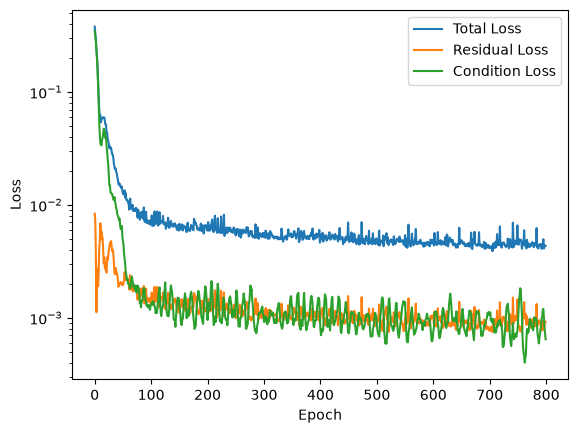

In [3]:
#| code-summary: "RelaxNN scheme for 1D Jin-Xin relaxation system"
class RelaxNN(nn.Module):
    def __init__(self, d: int):
        super(RelaxNN, self).__init__()
        self.d = d
        self.encoder = nn.Sequential(
            nn.Linear(1+self.d, 64),
            nn.SiLU(),
            nn.Linear(64, 512),
            nn.SiLU(),
            nn.Linear(512, 512),
            nn.SiLU(),
        )
        self.head_u = nn.Sequential(
            nn.SiLU(),
            nn.Linear(512, 64),
            nn.SiLU(),
            nn.Linear(64, 1),
            nn.Softplus(),
        )
        self.head_w = nn.Sequential(
            nn.SiLU(),
            nn.Linear(512, 64),
            nn.SiLU(),
            nn.Linear(64, self.d),
            nn.Identity(),
        )

    def forward(self, xt):
        lat_vec = self.encoder(xt)
        u = self.head_u(lat_vec)  # shape (N, 1)
        w = self.head_w(lat_vec)  # shape (N, d)
        return torch.cat([u, w], dim=-1)  # shape (N, 1 + d)

def u0(x: torch.Tensor) -> torch.Tensor:
    return torch.exp(-0.5 * torch.sum(x**2, dim=-1))  # initial condition for u
def v0(x: torch.Tensor, d: int) -> torch.Tensor:
    return f(u0(x), d=d)  # shape (N, d)

def residual_loss_fn(model: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, t: torch.Tensor, eps: float, D: tuple):
    # x has shape (N, d) and t has shape (N,) or (N, 1)
    model_in = torch.cat([t, x], dim=-1)  # shape (N, d + 1)
    jacob = dfu.compute_jacobian(model, model_in)  # shape (N, d+1, d+1)
    
    u_w = model(model_in)  # shape (N, d+1)
    u = u_w[:, 0]  # shape (N,)
    w = u_w[:, 1:]  # shape (N,d)
    
    Dtu_w = jacob[:, :, 0]  # shape (N, d+1)
    Dxu_w = jacob[:, :, 1:]  # shape (N, d+1, d)
    
    Dtu = Dtu_w[:, 0]  # shape (N,)
    Dtw = Dtu_w[:, 1:]  # shape (N, d)
    Dxu = Dxu_w[:, 0]  # shape (N, d)
    Dxw = Dxu_w[:, 1:]  # shape (N, d, d)
    Divxw = torch.einsum('nii->n', Dxw)  # shape (N,)
    df_u = df(u, model.d)  # shape (N, d)
    
    res1 = Dtu + torch.einsum('ni, ni -> n', df_u, Dxu) + eps * Divxw  # shape (N,)
    res2 = w + df_u * Dtu[:, None] + torch.tensor(D) * Dxu + eps * Dtw # shape (N, d)
    
    res = torch.concatenate([res1[:, None], res2], dim=-1)  # shape (N, 1 + d)
    
    loss1 = torch.mean(res1 ** 2)
    loss2 = torch.mean(res2 ** 2)
    loss = torch.max(loss1, loss2)
    
    return loss, res

def condition_loss_fn(model: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, eps: float):
    # x has shape (N, 1)
    
    u_w = model(torch.cat([torch.zeros_like(x[:,[0]]), x], dim=-1))  # shape (N, 1+d)
    u = u_w[:, 0]  # shape (N,)
    w = u_w[:, 1:]  # shape (N,d)
    
    v = f(u, model.d) + eps * w
    
    res_u = u - u0(x)  # shape (N,)
    res_v = v - v0(x, model.d)  # shape (N,d)
    
    res = torch.concatenate([res_u[:, None], res_v], dim=-1)  # shape (N, 1 + d)
    loss_u = torch.mean(res_u ** 2)
    loss_v = torch.mean(res_v ** 2)
    loss = torch.max(loss_u, loss_v)
    
    return loss, res

model1D = RelaxNN(d=1)

optimizer = torch.optim.Adam(model1D.parameters(), lr=0.001)

eps = 0.005
a = 1.1
T = 5.0
L = 10.0
n_samples = 2048

Rloss_history = []
Closs_history = []
loss_history = []
for epoch in tqdm(range(800), leave=True):
    optimizer.zero_grad()
    x = (torch.rand(n_samples, 1)*2-1)*L/2  # shape (N, d)
    t = torch.rand(n_samples, 1)*T  # shape (N, 1)
    Rloss, _ = residual_loss_fn(model1D, x, t, eps, (a,))
    
    x = (torch.rand(n_samples, 1)*2-1)*L/2  # shape (N, d)
    Closs, _ = condition_loss_fn(model1D, x, eps)
    
    loss = 4*Rloss + Closs
    
    loss_history.append(loss.item())
    Rloss_history.append(Rloss.item())
    Closs_history.append(Closs.item())
    loss.backward()
    optimizer.step()
    
plt.plot(loss_history, label='Total Loss')
plt.plot(Rloss_history, label='Residual Loss')
plt.plot(Closs_history, label='Condition Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

In [8]:
#| echo: false
#| code-summary: "animation in html"
#| show-output: false
"""
N = 1000
fps = 24
frames = int(fps * T)
Dt = 1/fps

xpin = torch.linspace(-L/2, L/2, N)  # shape (N,)
tpin = torch.linspace(0, T, frames)  # shape (frames,)
t, x = torch.meshgrid(tpin, xpin, indexing='ij')  # shape (frames, N)
xflat = x.flatten()  # shape (frames*N,)
tflat = t.flatten()  # shape (frames*N,)
_, res = residual_loss_fn(model1D, xflat.unsqueeze(-1), tflat.unsqueeze(-1), eps, (a,))  # shape (frames*N,2)
reshaped_res = res.reshape(frames, N, 2)  # shape (frames, N, 2)
uw = model1D(torch.cat([tflat.unsqueeze(-1), xflat.unsqueeze(-1)], dim=-1)).reshape(frames, N, 2)  # shape (frames, N, 2)
u = uw[..., 0]  # shape (frames, N)
w = uw[..., 1]  # shape (frames, N)
v = f(u.reshape(-1), model1D.d)[:,0].reshape(frames,N) + eps * w  # shape (N, N)

# creo 2 subplots per visualizzare u e v separatamente
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
value_min = reshaped_res.min().item()
value_max = reshaped_res.max().item()
value = max(abs(value_min), abs(value_max))
ax1.imshow(reshaped_res[:,:,0].detach().numpy(), extent=[-L/2, L/2, 0, T], vmin=-value, vmax=value, cmap='seismic', origin='lower', aspect='auto')
ax1.set_title('Transport')
cbar1 = fig.colorbar(ax1.imshow(reshaped_res[:,:,0].detach().numpy(), extent=[-L/2, L/2, 0, T], vmin=-value, vmax=value, cmap='seismic', origin='lower', aspect='auto'), ax=ax1)
ax2.imshow(reshaped_res[:,:,1].detach().numpy(), extent=[-L/2, L/2, 0, T], vmin=-value, vmax=value, cmap='seismic', origin='lower', aspect='auto')
ax2.set_title('JinXin')
cbar2 = fig.colorbar(ax2.imshow(reshaped_res[:,:,1].detach().numpy(), extent=[0, T, -L/2, L/2], vmin=-value, vmax=value, cmap='seismic', origin='lower', aspect='auto'), ax=ax2)
# save figure
fig.savefig("relaxNN_lossplot.png", dpi=300, bbox_inches='tight')
plt.close(fig)

# animation in html
x_np = xpin.detach().numpy()
u_np = u.detach().numpy()
v_np = v.detach().numpy()
u0_np = u0(xpin.unsqueeze(-1)).detach().numpy()
fig, ax = plt.subplots(figsize=(8, 4.5))
lineu, = ax.plot([], [], label=r"$u$", lw=2, color='blue')
linev, = ax.plot([], [], label=r"$v$", lw=2, color='orange')
lineu0, = ax.plot([], [], label=r"$u_0$", lw=1, color='black', linestyle='--')
title = ax.text(0.5, 1.02, "", transform=ax.transAxes, ha="center")
ax.set_xlim(-L/2, L/2)
ax.set_ylim(0, 1)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u(x,t)$")
ax.legend()
ax.grid(True, alpha=0.3)

def init():
    lineu.set_data([], [])
    linev.set_data([], [])
    lineu0.set_data(x_np, u0_np)
    title.set_text("")
    return lineu, linev, title

def update(frame):
    lineu.set_data(x_np, u_np[frame])
    linev.set_data(x_np, v_np[frame])
    title.set_text(rf"Time $t = {frame * Dt:.2f}\,\mathrm{{s}}$")
    return lineu, linev, title

ani = FuncAnimation(
    fig,
    update,
    frames=frames,
    init_func=init,
    interval=Dt*1000,  # interval in milliseconds
    blit=True
)

ani.save("relaxNN_simulation.gif", writer=PillowWriter(fps=fps), dpi=200)
plt.close(fig)
"""
pass

<>:64: SyntaxWarning: invalid escape sequence '\,'
<>:64: SyntaxWarning: invalid escape sequence '\,'
C:\Users\Stefano\AppData\Local\Temp\ipykernel_10776\1908244780.py:64: SyntaxWarning: invalid escape sequence '\,'
  title.set_text(rf"Time $t = {frame * Dt:.2f}\,\mathrm{{s}}$")


<img src="relaxNN_lossplot.png" alt="RelaxNN Loss Plot" width="600"><br>

<img src="relaxNN_simulation.gif" alt="RelaxNN Jin-Xin relaxation animation" width="600">

  0%|          | 0/1200 [00:00<?, ?it/s]

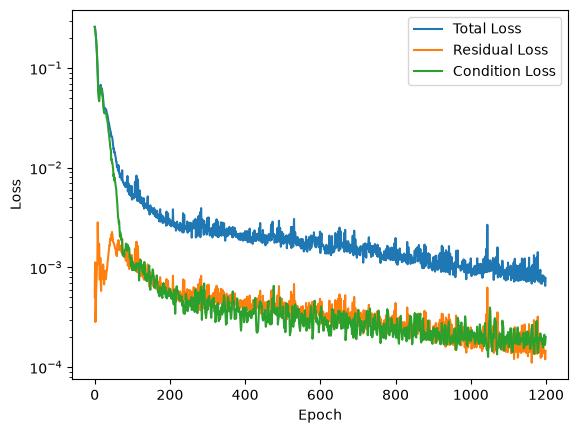

In [9]:
#| code-summary: "RelaxNN scheme for 2D Jin-Xin relaxation system"
def u0(x: torch.Tensor) -> torch.Tensor:
    return torch.exp(-0.5 * torch.sum(x**2, dim=-1))  # initial condition for u
def v0(x: torch.Tensor, d: int) -> torch.Tensor:
    return f(u0(x), d=d)  # shape (N, d)

model2D = RelaxNN(d=2)

optimizer = torch.optim.Adam(model2D.parameters(), lr=0.001)   

eps = 0.05
a, b = 1.1, 1.1
T = 5.0
L = 5.0
n_samples = 2048

Rloss_history = []
Closs_history = []
loss_history = []
for epoch in tqdm(range(1200), leave=True):
    optimizer.zero_grad()
    x = (torch.rand(n_samples, 2)*2-1)*L/2  # shape (N, d)
    t = torch.rand(n_samples, 1)*T  # shape (N, 1)
    Rloss, _ = residual_loss_fn(model2D, x, t, eps, (a, b))
    
    x = (torch.rand(n_samples, 2)*2-1)*L/2  # shape (N, d)
    Closs, _ = condition_loss_fn(model2D, x, eps)
    
    loss = 4*Rloss + Closs
    
    loss_history.append(loss.item())
    Rloss_history.append(Rloss.item())
    Closs_history.append(Closs.item())
    loss.backward()
    optimizer.step()
    
plt.plot(loss_history, label='Total Loss')
plt.plot(Rloss_history, label='Residual Loss')
plt.plot(Closs_history, label='Condition Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

In [10]:
#| echo: false
#| code-summary: "animation in html"
#| show-output: false
"""
with torch.no_grad():
    N = 100
    fps = 30
    nT = int(fps * T)
    Dt = T / nT

    x = torch.linspace(-L/2, L/2, N)  # shape (N,)
    y = torch.linspace(-L/2, L/2, N)  # shape (N,)
    t = torch.linspace(0, T, nT)  # shape (nT,)
    X, Y, T_grid = torch.meshgrid(x, y, t, indexing='ij')  # shape (N, N, nT)
    xflat = torch.stack([X.flatten(), Y.flatten()], dim=-1)  # shape (N*N*nT, 2)
    tflat = T_grid.flatten()  # shape (N*N*nT,)
    uw = model2D(torch.cat([tflat.unsqueeze(-1), xflat], dim=-1)).reshape(N, N, nT, 3)  # shape (N, N, nT, 3)
    u = uw[..., 0]  # shape (N, N, nT)
    r = eps*torch.norm(uw[..., 1:], dim=-1)  # shape (N, N, nT)
    _, res = residual_loss_fn(model2D, xflat, tflat.unsqueeze(-1), eps, (a, b))  # shape (N*N*nT, 3)
    reshaped_res = res.reshape(N, N, nT, 3)  # shape (N, N, nT, 3)
    res1 = reshaped_res[..., 0]  # shape (N, N, nT)
    res2 = torch.norm(reshaped_res[..., 1:], dim=-1)  # shape (N, N, nT)

    x_np = x.numpy()
    u_np = u.cpu().numpy()  # downsample to match the desired number of nT
    r_np = r.cpu().numpy()  # downsample to match the desired number of nT

    # 4 subplots: u, r, res1, res2
    # in una griglia 2x2, con u e r in alto, res1 e res2 in basso
    # uso plt.subplots(2, 2, figsize=(14, 14))
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 14))
    extent = [-L/2, L/2, -L/2, L/2]
    max_r = np.max(np.abs(r_np)) 
    max_res1 = np.max(np.abs(res1.cpu().numpy()))
    max_res2 = np.max(np.abs(res2.cpu().numpy()))
    if max_r == 0: max_r = 1e-5
    im_u = ax1.imshow(u_np[0], extent=extent, origin='lower', cmap='viridis', 
                    vmin=0.0, vmax=1.0, animated=True)
    im_r = ax2.imshow(r_np[0], extent=extent, origin='lower', cmap='gray',
                        vmin=0, vmax=max_r, animated=True)
    im_res1 = ax3.imshow(res1[:,:,0].cpu().numpy(), extent=extent, origin='lower', cmap='seismic',
                        vmin=-max_res1, vmax=max_res1, animated=True)
    im_res2 = ax4.imshow(res2[:,:,0].cpu().numpy(), extent=extent, origin='lower', cmap='gray',
                        vmin=0, vmax=max_res2, animated=True)
    fig.colorbar(im_u, ax=ax1, pad=0.04, label=r"$u(x,y)$")
    fig.colorbar(im_r, ax=ax2, pad=0.04, label=r"$v - f(u)$")
    fig.colorbar(im_res1, ax=ax3, pad=0.04, label=r"$\mathrm{res}_1$")
    fig.colorbar(im_res2, ax=ax4, pad=0.04, label=r"$\mathrm{res}_2$")
    ax1.set_title(r"Macro $u$")
    ax2.set_title(r"Deviation $\left\|v - f(u)\right\|$")
    ax3.set_title(r"Macro Residual")
    ax4.set_title(r"Micro Residual")
    for ax in (ax1, ax2):
        ax.set_xlabel("x")
        ax.set_ylabel("y")
    title = fig.suptitle(r"Time $t = 0.00\,\mathrm{s}$", fontsize=16)
    plt.tight_layout()

    def init():
        im_u.set_data(u_np[:,:,0])
        im_r.set_data(r_np[:,:,0])
        im_res1.set_data(res1[:,:,0].cpu().numpy())
        im_res2.set_data(res2[:,:,0].cpu().numpy())
        title.set_text(r"Time $t = 0.00\,\mathrm{s}$")
        return im_u, im_r, im_res1, im_res2, title

    def update(frame):
        im_u.set_data(u_np[:,:,frame])
        im_r.set_data(r_np[:,:,frame])
        im_res1.set_data(res1[:,:,frame].cpu().numpy())
        im_res2.set_data(res2[:,:,frame].cpu().numpy())
        title.set_text(rf"Time $t = {frame * Dt:.2f}\,\mathrm{{s}}$")
        return im_u, im_r, im_res1, im_res2, title

    ani = FuncAnimation(
        fig,
        update,
        frames=nT,
        init_func=init,
        interval=1000/fps, # Intervallo in millisecondi
        blit=True
    )

    ani.save("relaxNN_simulation_2D.gif", writer=PillowWriter(fps=fps), dpi=150)
    plt.close(fig)
"""
pass

<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Stefano\AppData\Local\Temp\ipykernel_10776\1896393607.py:48: SyntaxWarning: invalid escape sequence '\m'
  fig.colorbar(im_res1, ax=ax3, pad=0.04, label=r"$\mathrm{res}_1$")


<img src="relaxNN_simulation_2D.gif" alt="IMEX 2D Jin-Xin relaxation animation" width="600">